# Data Analysis: Perceived Usefulness
This script contains the data analysis for Perceived Usefulness.

### Content:
* Stacked percentage bar chart
* Mean and SD per group
* Omega Coefficient
* Normality check (Shapiro-Wilk & Q-Q plot)
* Aligned Rank Transform (ART) ANOVA

In [1]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 3.0 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import pingouin as pg
import scipy.stats as stats
import statsmodels.api as sm
import pylab as py

# Load data (csv format)

file_path = "/content/results-filtered-94.csv" # Replace with your filename
df = pd.read_csv(file_path, sep=";")

print(f"Data shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Removes the string descriptions in the data
df = df.replace("7 (strongly agree)", "7")
df = df.replace("1 (strongly disagree)", "1")

# Transform strings to numeric values
df["PO3U[SQ001]"] = pd.to_numeric(df["PO3U[SQ001]"], errors="coerce")
df["PO3U[SQ003]"] = pd.to_numeric(df["PO3U[SQ003]"], errors="coerce")
df["PO3U[SQ004]"] = pd.to_numeric(df["PO3U[SQ004]"], errors="coerce")
df["PO3U[SQ005]"] = pd.to_numeric(df["PO3U[SQ005]"], errors="coerce")
df["PO3U[SQ006]"] = pd.to_numeric(df["PO3U[SQ006]"], errors="coerce")

# Define dimension items
dimension_items = ["PO3U[SQ001]", "PO3U[SQ003]", "PO3U[SQ004]", "PO3U[SQ005]", "PO3U[SQ006]"]

# Create a subset dataframe containing just these items
df_dim = df[dimension_items].dropna()



Data shape: 94 rows, 80 columns



Stacked percentage bar chart

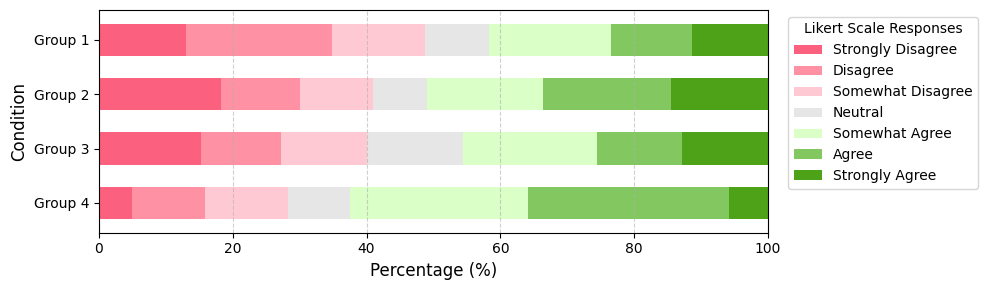

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

dimensions = {
    "Perceived Usefulness": dimension_items
}

likert_labels = [
    "Strongly Disagree",
    "Disagree",
    "Somewhat Disagree",
    "Neutral",
    "Somewhat Agree",
    "Agree",
    "Strongly Agree",
]

# Aggregate raw responses into percentages
rows = []

# Loop through each group and dimensions
for group_num in sorted(df["group"].unique()):
    group_data = df[df["group"] == group_num]

    for dim_name, item_list in dimensions.items():
        # Flatten items for this dimension into a single row
        flat_responses = group_data[item_list].values.flatten()

        # Count frequencies of scores 1 through 7
        counts = pd.Series(flat_responses).value_counts()

        # Fill scores with 0 counts
        counts = counts.reindex(range(1, 8), fill_value=0)

        # Convert counts into percentages that sum up to 100%
        percentages = (counts / counts.sum()) * 100

        # Save row data labeled by group
        row_entry = {"Label": f"Group {group_num}"}
        for i, score_name in enumerate(likert_labels):
            row_entry[score_name] = percentages.iloc[i]

        rows.append(row_entry)

# Convert processed list into a plotting DataFrame
df_plot = pd.DataFrame(rows).set_index("Label")

likert_colors = [
    "#fb607f",  # Strongly Disagree (Deep Red)
    "#ff91a4",  # Disagree (Light Red)
    "#ffc9d3",  # Somewhat Disagree (Pink)
    "#e6e6e6",  # Neutral (Light Gray)
    "#daffc7",  # Somewhat Agree (Light Green)
    "#83c760",  # Agree (Medium Green)
    "#4ea217",  # Strongly Agree (Deep Green)
]

fig, ax = plt.subplots(figsize=(10, 3))

# Plot horizontal stacked bar chart
df_plot.plot(
    kind="barh", stacked=True, color=likert_colors, width=0.6, ax=ax
)

# Reverse the vertical axis layout so group 1 appears at the top
ax.invert_yaxis()

ax.set_xlabel("Percentage (%)", fontsize=12)
ax.set_ylabel("Condition", fontsize=12)
ax.set_xlim(0, 100)
ax.xaxis.grid(True, linestyle="--", alpha=0.6)

# Position the legend outside the chart on the right side
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Likert Scale Responses",
    frameon=True,
)

plt.tight_layout()
plt.show()

In [6]:
# Aggregate data (mean & SD)

# Calculate the mean across the rows for x items
# This creates a new column in the original dataframe
df["Dimension_Mean_Score"] = df_dim.mean(axis=1)

# Calculate the mean of the participant means, grouped by the 'group' column
group_means = df.groupby('group')['Dimension_Mean_Score'].mean()
group_sd = df.groupby('group')['Dimension_Mean_Score'].std()

print("--- PU mean scores per group ---")
print(group_means)

# high sd = values are spread out further from mean
# low sd = data points cluster closer to mean
print("--- PU SD per group ---")
print(group_sd)

--- PU mean scores per group ---
group
1    3.800
2    4.100
3    4.016
4    4.550
Name: Dimension_Mean_Score, dtype: float64
--- PU SD per group ---
group
1    1.795955
2    1.989257
3    1.829317
4    1.455723
Name: Dimension_Mean_Score, dtype: float64


In [5]:
!Rscript -e "install.packages('psych', repos='https://cloud.r-project.org')"

%load_ext rpy2.ipython

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘mnormt’, ‘GPArotation’

trying URL 'https://cloud.r-project.org/src/contrib/mnormt_2.1.2.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/GPArotation_2026.6-1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/psych_2.6.5.tar.gz'
* installing *source* package ‘mnormt’ ...
** this is package ‘mnormt’ version ‘2.1.2’
** package ‘mnormt’ successfully unpacked and MD5 sums checked
** using staged installation
** libs
using C compiler: ‘cc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0’
using Fortran compiler: ‘GNU Fortran (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0’
f77  -fpic  -g -O2 -ffile-prefix-map=/build/r-base-gN72Ro/r-base-4.6.0=. -fstack-protector-strong  -c biv-nt.f -o biv-nt.o
cc -I"/usr/share/R/include" -DNDEBUG       -fpic  -g -O2 -ffile-prefix-map=/build/r-base-gN72Ro/r-base-4.6.0=. -fstack-protector-strong -Wformat -Werror=format-security -Wdate-time -D

In [7]:
%%R -i df_dim

library(psych)

# Calculate McDonald's Omega
# nfactors=1 because your 3 items belong to a single category/construct
omega_result <- omega(df_dim, nfactors=1, plot=FALSE)

print(omega_result)

Omega 
Call: omegah(m = m, nfactors = nfactors, fm = fm, key = key, flip = flip, 
    digits = digits, title = title, sl = sl, labels = labels, 
    plot = plot, n.obs = n.obs, rotate = rotate, Phi = Phi, option = option, 
    covar = covar)
Alpha:                 0.95 
G.6:                   0.95 
Omega Hierarchical:    0.95 
Omega H asymptotic:    1 
Omega Total            0.95 

Schmid Leiman Factor loadings greater than  0.2 
               g  F1*   h2   h2   u2 p2 com
PO3U[SQ001] 0.88      0.77 0.77 0.23  1   1
PO3U[SQ003] 0.89      0.79 0.79 0.21  1   1
PO3U[SQ004] 0.89      0.79 0.79 0.21  1   1
PO3U[SQ005] 0.88      0.78 0.78 0.22  1   1
PO3U[SQ006] 0.87      0.76 0.76 0.24  1   1

With Sums of squares  of:
  g F1*  h2 
3.9 0.0 3.0 

general/max  1.28   max/min =   Inf
mean percent general =  1    with sd =  0 and cv of  0 
Explained Common Variance of the general factor =  1 

The degrees of freedom are 5  and the fit is  0.76 
The number of observations was  94  with Chi Squa

Loading required namespace: GPArotation
Omega_h for 1 factor is not meaningful, just omega_t
In addition: Warning messages:
1: In schmid(m, nfactors, fm, digits, rotate = rotate, n.obs = n.obs,  :
  Omega_h and Omega_asymptotic are not meaningful with one factor
2: In cov2cor(t(w) %*% r %*% w) :
  diag(V) had non-positive or NA entries; the non-finite result may be dubious


--- PU Normality Check (Shapiro-Wilk) ---
                             W      pval  normal
Dimension_Mean_Score  0.963193  0.009553   False

--- PU Normality Check (Q-Q Plot) ---


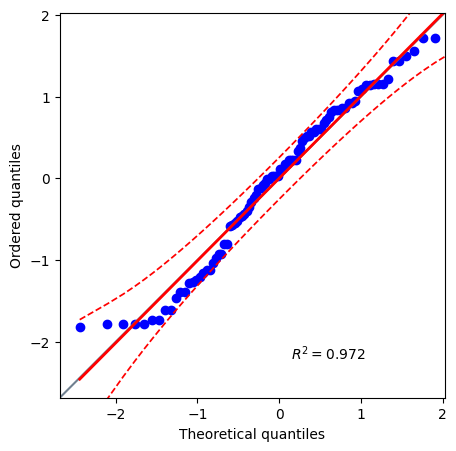

In [8]:
# Normality check
import matplotlib.pyplot as plt
import pingouin as pg

print("--- PU Normality Check (Shapiro-Wilk) ---")

# Extract the residuals
residuals = df["Dimension_Mean_Score"] - df.groupby(
    'group'
)["Dimension_Mean_Score"].transform("mean")

# Drop any NaN values from the residuals array
clean_residuals = residuals.dropna()

# Shapiro-Wilk Test
# p > 0.05 == data is normally distributed
shapiro_test = pg.normality(clean_residuals)
print(shapiro_test)
print()
print("--- PU Normality Check (Q-Q Plot) ---")
plt.figure(figsize=(6, 5))
pg.qqplot(clean_residuals, dist="norm")
plt.show()

In [9]:
# Prepare independent variables for two-way ANOVA

language_mapping = {
    1: "Gender-Specific",
    2: "Gender-Neutral",
    3: "Gender-Specific",
    4: "Gender-Neutral"
}

style_mapping = {
    1: "Empathetic",
    2: "Empathetic",
    3: "Neutral",
    4: "Neutral"
}

df['Language'] = df['group'].map(language_mapping)
df['Style'] = df['group'].map(style_mapping)

print("Preview of decoded groups:")
print(df[['group', 'Language', 'Style']].drop_duplicates().to_string(index=False))


Preview of decoded groups:
 group        Language      Style
     3 Gender-Specific    Neutral
     2  Gender-Neutral Empathetic
     1 Gender-Specific Empathetic
     4  Gender-Neutral    Neutral


ART ANOVA

In [10]:
# Create a subset with only the columns needed for the test

df_clean = df[['Dimension_Mean_Score', 'Language', 'Style']].dropna()

print(f"Data for R: {df_clean.shape[0]} rows and {df_clean.shape[1]} columns")

Data for R: 94 rows and 3 columns


In [11]:
%%R -i df_clean

if (!require(ARTool)) {
  install.packages("ARTool")
  library(ARTool)
}
if (!require(dplyr)) {
  install.packages("dplyr")
  library(dplyr)
}
if (!require(lme4)) {
  install.packages("lme4")
  library(lme4)
}

Loading required package: ARTool
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘lme4’, ‘car’, ‘plyr’, ‘emmeans’

trying URL 'https://cran.rstudio.com/src/contrib/colorspace_2.1-3.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/fracdiff_1.5-4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/lmtest_0.9-40.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/timeDate_4052.112.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/urca_1.3-4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/zoo_1.8-15.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/RcppArmadillo_15.4.0-1.tar.gz'


In [12]:
%%R -i df_clean

df_clean$Language <- as.factor(df_clean$Language)
df_clean$Style    <- as.factor(df_clean$Style)

# Fit the Aligned Rank Transform model
# Format: Dependent_Variable ~ Factor1 * Factor2
art_model <- art(Dimension_Mean_Score ~ Language * Style, data = df_clean)

art_anova <- anova(art_model)

# verbose=TRUE to print sums of squares
print(art_anova, verbose=TRUE)

# To get partial eta-squared
art_anova$eta.sq.part = with(art_anova, `Sum Sq`/(`Sum Sq` + `Sum Sq.res`))
art_anova


Analysis of Variance of Aligned Rank Transformed Data

Table Type: Anova Table (Type III tests) 
Model: No Repeated Measures (lm)
Response: art(Dimension_Mean_Score)

                 Df Df.res   Sum Sq Sum Sq.res F value  Pr(>F)  
1 Language        1     90 1086.100      68082 1.43576 0.23397  
2 Style           1     90  351.968      68817 0.46031 0.49922  
3 Language:Style  1     90   70.065      69105 0.09125 0.76329  
---
Signif. codes:   0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1 
Analysis of Variance of Aligned Rank Transformed Data

Table Type: Anova Table (Type III tests) 
Model: No Repeated Measures (lm)
Response: art(Dimension_Mean_Score)

                 Df Df.res F value  Pr(>F) eta.sq.part  
1 Language        1     90 1.43576 0.23397   0.0157024  
2 Style           1     90 0.46031 0.49922   0.0050885  
3 Language:Style  1     90 0.09125 0.76329   0.0010129  
---
Signif. codes:   0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1 
